# 04 — Sentiment Model Training
Fine-tunes `distilbert-base-uncased` (a generic pre-trained model, NOT pre-fine-tuned for sentiment) on the **Claude API–labeled dataset** produced in `02b_label_data`.

This satisfies the restriction:
> *'You may not use a model from Hugging Face that has already been fine-tuned for sentiment.'*

The base model is confirmed at: https://huggingface.co/distilbert/distilbert-base-uncased (only masked language modelling pre-training — no downstream fine-tuning)

**Label mapping** (matches `02b_label_data` exactly):
- `0` = negative — AI harms/disrupts the industry or company
- `1` = neutral  — no clear directional impact
- `2` = positive — AI benefits the industry or company

In [1]:
!pip install -q datasets transformers evaluate accelerate scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import evaluate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for d in ["models", "outputs", "figures"]:
    Path(d).mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [3]:
# ── confirm base model is NOT pre-fine-tuned for sentiment ───────────────────
# distilbert-base-uncased is a general-purpose masked LM.
# Do NOT change this to distilbert-base-uncased-finetuned-sst-2-english
# or any other sentiment-specific model — that would violate the restriction.
BASE_MODEL = "distilbert-base-uncased"
print(f"Base model: {BASE_MODEL}")
print("Confirmed: generic pre-trained LM, no prior sentiment fine-tuning.")

Base model: distilbert-base-uncased
Confirmed: generic pre-trained LM, no prior sentiment fine-tuning.


In [4]:
# ── load Claude API-labeled training data (output of 02b_label_data) ─────────
#
# Data source: 5,000 articles labeled by Claude API in 02b_label_data
# Labels are project-specific (AI impact on industries), NOT generic finance sentiment.
#
# Label map (identical to 02b):
#   0 = negative, 1 = neutral, 2 = positive

df_labeled = pd.read_parquet("data/labeled_5000.parquet")
print(f"Loaded {len(df_labeled):,} labeled articles from 02b_label_data")

print("\nLabel distribution:")
label_counts = df_labeled["label"].value_counts()
print(label_counts)

print("\nConfidence stats:")
print(df_labeled["confidence"].describe().round(3))

df_labeled[["title", "label", "label_id", "confidence"]].head(3)

Loaded 4,067 labeled articles from 02b_label_data

Label distribution:
label
positive    2718
neutral      682
negative     667
Name: count, dtype: int64

Confidence stats:
count    4067.000
mean        0.793
std         0.071
min         0.700
25%         0.700
50%         0.800
75%         0.850
max         0.970
Name: confidence, dtype: float64


,title,label,label_id,confidence
0,Xmpro Named A Sample Vendor For Agentic AI In ...,positive,2,0.85
1,"Despite AI enthusiasm, Workforce Index reveals...",negative,0,0.80
2,Top 13 Ways Artificial Intelligence Has Change...,positive,2,0.80


In [5]:
# ── train / test split (80/20, stratified) ───────────────────────────────────
df_train, df_test = train_test_split(
    df_labeled,
    test_size=0.2,
    random_state=42,
    stratify=df_labeled["label_id"]   # preserve label proportions
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train):,}  |  Test: {len(df_test):,}")

# Convert to HuggingFace Dataset
# Column name 'sentence' matches the tokenize() function below (same as before)
train_ds = Dataset.from_dict({
    "sentence": df_train["article_text"].tolist(),
    "label":    df_train["label_id"].tolist(),
})
test_ds = Dataset.from_dict({
    "sentence": df_test["article_text"].tolist(),
    "label":    df_test["label_id"].tolist(),
})

split = DatasetDict({"train": train_ds, "test": test_ds})
print(split)

# Verify label distribution in train
train_label_counts = pd.Series(df_train["label_id"]).value_counts().sort_index()
train_label_counts.index = ["negative", "neutral", "positive"]
print("\nTrain label distribution:")
print(train_label_counts)

Train: 3,253  |  Test: 814
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 3253
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 814
    })
})

Train label distribution:
negative     534
neutral      545
positive    2174
Name: count, dtype: int64


In [6]:
# ── tokenise ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

tokenized = split.map(tokenize, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenisation complete.")

Map:   0%|          | 0/3253 [00:00<?, ? examples/s]

Map:   0%|          | 0/814 [00:00<?, ? examples/s]

Tokenisation complete.


In [7]:
# ── model ─────────────────────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,
    id2label={0: "negative", 1: "neutral", 2: "positive"},
    label2id={"negative": 0, "neutral": 1, "positive": 2},
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,779


In [8]:
# ── metrics ───────────────────────────────────────────────────────────────────
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_metric.compute(
            predictions=preds, references=labels
        )["accuracy"],
        "macro_f1": f1_metric.compute(
            predictions=preds, references=labels, average="macro"
        )["f1"],
        "weighted_f1": f1_metric.compute(
            predictions=preds, references=labels, average="weighted"
        )["f1"],
    }

In [9]:
training_args = TrainingArguments(
    output_dir="models/sentiment_distilbert",
    eval_strategy="epoch",          # renamed from evaluation_strategy in transformers>=4.45
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    processing_class=tokenizer,     # renamed from tokenizer in transformers>=4.45
    compute_metrics=compute_metrics,
)

trainer.train()

c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,No log,0.439186,0.840295,0.731662,0.826516
2,No log,0.410698,0.852580,0.764099,0.845147
3,0.438348,0.419183,0.855037,0.786059,0.854915


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=612, training_loss=0.40069031871222205, metrics={'train_runtime': 4191.4458, 'train_samples_per_second': 2.328, 'train_steps_per_second': 0.146, 'total_flos': 323193099458304.0, 'train_loss': 0.40069031871222205, 'epoch': 3.0})

In [10]:
# ── evaluate ──────────────────────────────────────────────────────────────────
eval_results = trainer.evaluate()
print("\n=== Final Evaluation ===")
for k, v in eval_results.items():
    print(f"  {k}: {v:.4f}")

pd.DataFrame([eval_results]).to_csv("outputs/sentiment_eval_results.csv", index=False)

c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.438348,0.419183,3,0.855037,0.786059,0.854915



=== Final Evaluation ===
  eval_loss: 0.4192
  eval_accuracy: 0.8550
  eval_macro_f1: 0.7861
  eval_weighted_f1: 0.8549


c:\Users\lola\anaconda3\envs\sentiment_hw\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


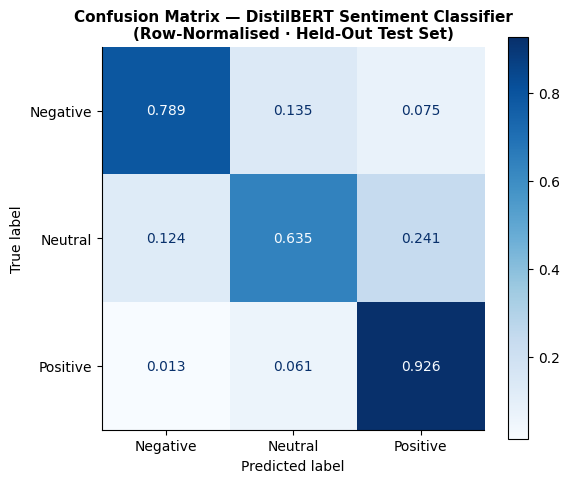

In [11]:
# ── confusion matrix ──────────────────────────────────────────────────────────
import torch

preds_output = trainer.predict(tokenized["test"])
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

# Row-normalised confusion matrix (matches figure format shown in project brief)
cm      = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
labels_str = ["Negative", "Neutral", "Positive"]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels_str)
disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format=".3f")
ax.set_title(
    "Confusion Matrix — DistilBERT Sentiment Classifier\n(Row-Normalised · Held-Out Test Set)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("figures/sentiment_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

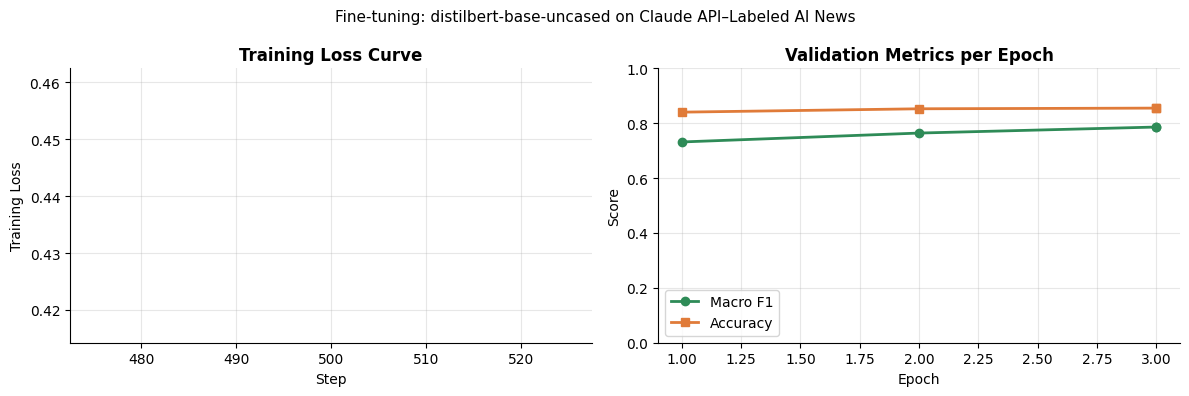

In [12]:
# ── training curve ────────────────────────────────────────────────────────────
log_history = pd.DataFrame(trainer.state.log_history)

train_log = log_history.dropna(subset=["loss"]).copy()
eval_log  = log_history.dropna(subset=["eval_macro_f1"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_log["step"], train_log["loss"], color="#4C72B0", linewidth=1.5)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss Curve", fontweight="bold")
axes[0].grid(alpha=0.3)

axes[1].plot(eval_log["epoch"], eval_log["eval_macro_f1"],
             marker="o", color="#2E8B57", linewidth=2, label="Macro F1")
axes[1].plot(eval_log["epoch"], eval_log["eval_accuracy"],
             marker="s", color="#E07B39", linewidth=2, label="Accuracy")
axes[1].legend()
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics per Epoch", fontweight="bold")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Fine-tuning: distilbert-base-uncased on Claude API–Labeled AI News",
    fontsize=11
)
plt.tight_layout()
plt.savefig("figures/sentiment_training_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ── save final model ──────────────────────────────────────────────────────────
FINAL_MODEL_PATH = "models/sentiment_distilbert_final"
trainer.save_model(FINAL_MODEL_PATH)
tokenizer.save_pretrained(FINAL_MODEL_PATH)
print(f"Model saved to {FINAL_MODEL_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to models/sentiment_distilbert_final


In [14]:
# ── release memory to prevent kernel crash ────────────────────────────────────
import gc

del model
del trainer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Memory released. Safe to run 05_analysis next.")

Memory released. Safe to run 05_analysis next.
